# TP3 - Aprendizaje Supervisado y/o No Supervisado

Autores: Ana Paula Cobresí, Gonzalo Angaut, Javier Albiero y Octavio Santi.

## Introducción

Vamos a usar el _dataset_ generado en el TP2 para aplicar diferentes métodos de:
- Análisis Supervisado para hacer predicciones.
- Análisis No Supervisado para hacer agrupamiento o _clustering_, de los datos.

In [ ]:
%pip install scikit-optimize
%pip install skopt
%pip install tabulate
%pip install xgboost
%pip install yellowbrick

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from numpy import ndarray
from pandas import DataFrame
from sklearn.cluster import KMeans, MeanShift, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    auc, confusion_matrix, f1_score, roc_curve, roc_auc_score,
    silhouette_score, davies_bouldin_score, balanced_accuracy_score,
    accuracy_score, precision_score, recall_score, classification_report,
    precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler, label_binarize
from sklearn.neighbors import NearestNeighbors
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight
from sklearn.base import BaseEstimator, ClassifierMixin
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from tabulate import tabulate
from xgboost import XGBClassifier
from yellowbrick.cluster import SilhouetteVisualizer

# Usar None para evitar reproducibilidad
RANDOM_SEED = 0
np.random.seed(RANDOM_SEED) # Para skop.space.[Real, Integer, Categorical]

# Incrementar para mejor precisión y más tiempo de cálculo (ideal 31)
RFOREST_MAX_DEPTH = 31

# Incrementar para mejor precisión y más tiempo de cálculo (ideal 30 o 50)
BAYES_SEARCH_ITER = 30

Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement skopt (from versions: none)
ERROR: No matching distribution found for skopt
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


/home/jalbiero/bin/anaconda3/envs/mentoria/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
file_base_path = "https://raw.githubusercontent.com/jalbiero/unc-space-debris-datasets/refs/tags/v2.0.0/data"
# file_base_path = "." # acceso local

train_df = pd.read_csv(f"{file_base_path}/DatosDeEntrenamiento.csv")
eval_df = pd.read_csv(f"{file_base_path}/DatosDeEvaluacion.csv")
test_df = pd.read_csv(f"{file_base_path}/DatosDePrueba.csv")

train_df.info()
train_df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4140 entries, 0 to 4139
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   INFO_SATNAME                    4140 non-null   object 
 1   INFO_NORAD_NUMBER               4140 non-null   int64  
 2   INFO_OBJECT_TYPE                4140 non-null   object 
 3   INFO_TYPE_OF_ORBIT              3872 non-null   object 
 4   INFO_COUNTRY                    4140 non-null   object 
 5   INFO_CLASS_OF_ORBIT             4140 non-null   object 
 6   PERIOD                          4140 non-null   float64
 7   INCLINATION                     4140 non-null   float64
 8   APOGEE                          4140 non-null   float64
 9   PERIGEE                         4140 non-null   float64
 10  LAUNCH_YEAR                     4140 non-null   float64
 11  CURRENT                         4140 non-null   float64
 12  EXPECTED_LIFETIME_YRS           41

,INFO_SATNAME,INFO_NORAD_NUMBER,INFO_OBJECT_TYPE,INFO_TYPE_OF_ORBIT,INFO_COUNTRY,INFO_CLASS_OF_ORBIT,PERIOD,INCLINATION,APOGEE,PERIGEE,...,COUNTRY_GROUPED_PRC,COUNTRY_GROUPED_REST,COUNTRY_GROUPED_UK,COUNTRY_GROUPED_US,PURPOSE_COMMUNICATIONS,PURPOSE_EARTH_OBSERVATION,PURPOSE_OTHER,PURPOSE_TECHNOLOGY_DEVELOPMENT,RCS_SIZE_ENC,CLASS_OF_ORBIT_ENC
958,FLOCK 3P 50,42029,PAYLOAD,Sun-Synchronous,US,LEO,0.000133,0.986301,0.000278,0.000280,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2613,GHOST-2,56197,PAYLOAD,Sun-Synchronous,US,LEO,0.003854,0.987418,0.007137,0.007236,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.5,0.0
45,CENTAURI-1,43809,PAYLOAD,Sun-Synchronous,AUS,LEO,0.005944,0.988940,0.011080,0.010967,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3527,STARLINK-3581,51806,PAYLOAD,Non-Polar Inclined,US,LEO,0.000245,0.539625,0.000361,0.000617,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3896,ONEWEB-0228,48780,PAYLOAD,Polar,UK,LEO,0.016423,0.891832,0.029352,0.029927,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.5,0.0


## Aprendizaje supervisado

###1. Preparación de los Datos y Elección del Objetivo
En esta sección, vamos a analizar la base de datos y aplicar modelos de aprendizaje supervisado. La variable que elegimos para predecir en función del resto es `EXPECTED_LIFETIME_YRS`. Esto nos permitirá estimar la expectativa de vida de cada objeto y proyectar la cantidad aproximada de objetos que permanecerán en órbita en el futuro.

Realizaremos un modelo de clasificación, separando entre expectativa de vida corta, media y larga.

In [3]:
# Comenzamos haciendo una copia de todos los dataframes para no perder la información original
train_df_sl = train_df.copy()
eval_df_sl = eval_df.copy()
test_df_sl = test_df.copy()

La variable a predecir es `EXPECTED_LIFETIME_YRS`. Separamos las variables en datos de entrada X y la variable objetivo y. <br>Para los datos de entrada, eliminamos también las columnas que son únicamente informativas y no aportan valor predictivo:
- 'INFO_SATNAME',
- 'INFO_NORAD_NUMBER',
- 'INFO_OBJECT_TYPE',
- 'INFO_TYPE_OF_ORBIT',
- 'INFO_COUNTRY',
- 'INFO_CLASS_OF_ORBIT'
<br>
Después de esto, separamos los datos en X (Features) e Y (target), para train, validation y test.

In [4]:
# Columnas que no se usarán como features
drop_cols = [
    'EXPECTED_LIFETIME_YRS',
    'INFO_SATNAME',
    'INFO_NORAD_NUMBER',
    'INFO_OBJECT_TYPE',
    'INFO_TYPE_OF_ORBIT',
    'INFO_COUNTRY',
    'INFO_CLASS_OF_ORBIT'
]

# Datos de entrenamiento
X_train = train_df_sl.drop(columns=drop_cols)
y_train = train_df_sl['EXPECTED_LIFETIME_YRS']

# Datos de validación
X_eval = eval_df_sl.drop(columns=drop_cols)
y_eval = eval_df_sl['EXPECTED_LIFETIME_YRS']

# Datos de testeo
X_test = test_df_sl.drop(columns=drop_cols)
y_test = test_df_sl['EXPECTED_LIFETIME_YRS']


Veamos, por ejemplo, cómo quedaron los datos de entrenamiento:

In [5]:
X_train.head()

,PERIOD,INCLINATION,APOGEE,PERIGEE,LAUNCH_YEAR,CURRENT,LAUNCH_MASS_KG,TIME_IN_ORBIT,COUNTRY_GROUPED_CIS,COUNTRY_GROUPED_PRC,COUNTRY_GROUPED_REST,COUNTRY_GROUPED_UK,COUNTRY_GROUPED_US,PURPOSE_COMMUNICATIONS,PURPOSE_EARTH_OBSERVATION,PURPOSE_OTHER,PURPOSE_TECHNOLOGY_DEVELOPMENT,RCS_SIZE_ENC,CLASS_OF_ORBIT_ENC
0,0.000133,0.987620,0.000361,0.000196,0.956522,0.0,0.000652,0.056017,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.000289,0.537900,0.000417,0.000729,0.869565,0.0,0.036657,0.124020,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.006032,0.539827,0.010969,0.011387,0.956522,1.0,0.042033,0.054288,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.006032,0.539827,0.010969,0.011387,0.956522,1.0,0.042033,0.088290,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.009308,0.997869,0.016856,0.017333,0.608696,1.0,0.134897,0.417704,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [6]:
y_train.head()

0    0.076923
1    0.153846
2    0.153846
3    0.153846
4    0.403846
Name: EXPECTED_LIFETIME_YRS, dtype: float64

###2. Transformación del problema de regresión a clasificación
Notemos que `EXPECTED_LIFETIME_YRS` es una variable continua. Para hacer un modelo de clasificación necesitamos crear categorías.
<br>A estos fines, vamos a tener en cuenta la media (μ) y la desviación estándar (σ) de EXPECTED_LIFETIME_YRS y definir 3 categorías:

- Expectativa de vida media: Si la expectativa de vida se encuentra en el rango $\mu \pm \frac{1}{2} \sigma$, donde $\mu$ es la media y $\sigma$ la desviación estándar.

- Expectativa de vida corta: Si la expectativa de vida se encuentra por debajo del rango de expectativa de vida media.

- Expectativa de vida larga: Si la expectativa de vida se encuentra por encima del rango de expectativa de vida media.

Por lo tanto, ahora debemos cambiar los datos de salida para que, en lugar de tener los años, tengan el grupo al que pertenecen.

In [7]:
# Juntamos todas las salidas
all_y = pd.concat([y_train, y_eval, y_test], ignore_index=True)
# Calculamos media y desviación
mean_val = y_train.mean()
std_val = y_train.std()

# Definimos umbrales
low_threshold = mean_val - 0.5*std_val
high_threshold = mean_val + 0.5*std_val

In [8]:
# Asignamos clases
def assign_class(x):
    if x < low_threshold:
        return 0  # corta vida
    elif x > high_threshold:
        return 2  # larga vida
    else:
        return 1  # media

y_train_group = y_train.apply(assign_class)
y_eval_group = y_eval.apply(assign_class)
y_test_group = y_test.apply(assign_class)

In [9]:
y_train_group.head()

0    0
1    1
2    1
3    1
4    2
Name: EXPECTED_LIFETIME_YRS, dtype: int64

In [10]:
y_train_group.value_counts()

EXPECTED_LIFETIME_YRS
1    2990
0     630
2     520
Name: count, dtype: int64

Notemos que está bastante desbalanceada. Veamos gráficamente como quedaron los datos.

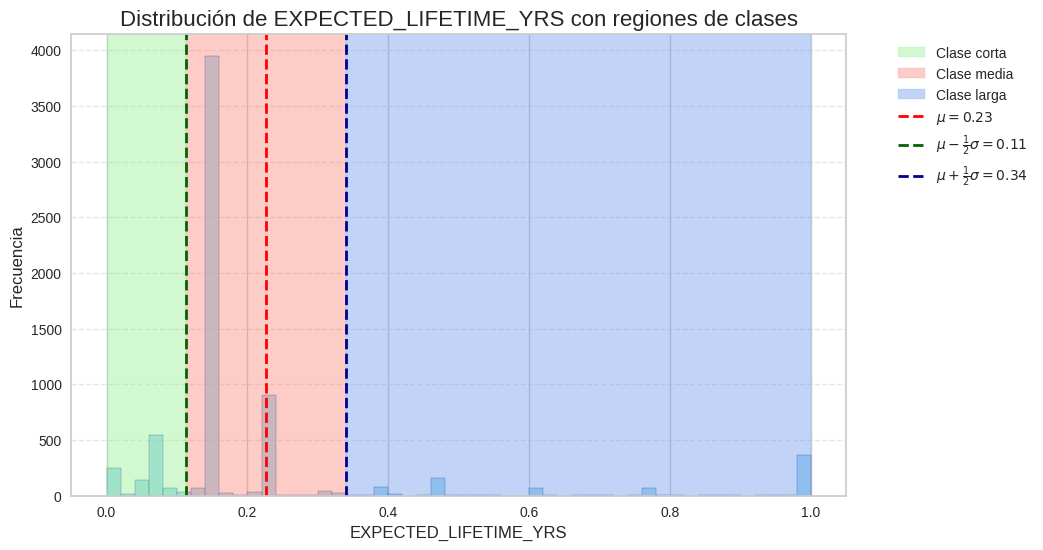

In [11]:
# Histograma
plt.figure(figsize=(10, 6))
plt.hist(all_y, bins=50, color="skyblue", edgecolor="navy", alpha=0.7)

# Sombreado de regiones
plt.axvspan(all_y.min(), low_threshold, color="lightgreen", alpha=0.4, label="Clase corta")
plt.axvspan(low_threshold, high_threshold, color="salmon", alpha=0.4, label="Clase media")
plt.axvspan(high_threshold, all_y.max(), color="cornflowerblue", alpha=0.4, label="Clase larga")

# Líneas de referencia
plt.axvline(mean_val, color="red", linestyle="--", linewidth=2,
            label=rf"$\mu = {mean_val:.2f}$")
plt.axvline(low_threshold, color="darkgreen", linestyle="--", linewidth=2,
            label=rf"$\mu - \frac{{1}}{{2}}\sigma = {low_threshold:.2f}$")
plt.axvline(high_threshold, color="darkblue", linestyle="--", linewidth=2,
            label=rf"$\mu + \frac{{1}}{{2}}\sigma = {high_threshold:.2f}$")


# Decoración
plt.title("Distribución de EXPECTED_LIFETIME_YRS con regiones de clases", fontsize=16)
plt.xlabel("EXPECTED_LIFETIME_YRS", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(axis='y', alpha=0.5, linestyle='--')

plt.show()

###3. Aplicación de Modelos:
Vamos a utilizar 3 modelos:
1. Random Forest
2. XGBoost
3. SVM

####A. Random Forest

Vamos a comenzar probando un método de Random Forest para predecir a qué grupo pertenece cada objeto espacial.<br>
Comenzamos haciendo una validación cruzada estratificada (10 folds) con los datos de entrenamiento.

In [12]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

rf = RandomForestClassifier(random_state=RANDOM_SEED,class_weight='balanced')

scores = cross_validate(
    rf,
    X_train,
    y_train_group,
    cv=cv,
    scoring=['roc_auc_ovr', 'f1_weighted'],
    return_train_score=False

)

metrics_table = [
    ["ROC-AUC", [f"{v:.4f}" for v in scores['test_roc_auc_ovr']], f"{scores['test_roc_auc_ovr'].mean():.4f}"],
    ["F1 Score", [f"{v:.4f}" for v in scores['test_f1_weighted']], f"{scores['test_f1_weighted'].mean():.4f}"]
]

print(tabulate(metrics_table, headers=["Métrica", "Scores por fold", "Media"], tablefmt="github"))

| Métrica   | Scores por fold                                                                                      |   Media |
|-----------|------------------------------------------------------------------------------------------------------|---------|
| ROC-AUC   | ['0.9969', '0.9978', '0.9969', '0.9963', '0.9966', '0.9979', '0.9990', '0.9986', '0.9998', '0.9997'] |  0.9979 |
| F1 Score  | ['0.9786', '0.9730', '0.9830', '0.9682', '0.9687', '0.9757', '0.9806', '0.9758', '0.9904', '0.9855'] |  0.9779 |


Notar que usamos `class_weight='balanced'` con el fin de tener en cuenta el desbalance de clases.

Como el modelo mostró un buen rendimiento en los distintos folds durante la validación cruzada, podemos entrenar un modelo final utilizando el conjunto de entrenamiento.

In [13]:
# Entrenamos el modelo completo
rf.fit(X_train, y_train_group)

RandomForestClassifier(class_weight='balanced', random_state=0)

Veamos como funciona el modelo entrenado con los datos de validación.

In [14]:
y_pred = rf.predict(X_eval)
y_proba = rf.predict_proba(X_eval)

print("F1 Score:", f1_score(y_eval_group, y_pred, average='weighted'))
print("ROC-AUC:", roc_auc_score(y_eval_group, y_proba, multi_class='ovr'))

F1 Score: 0.97526145748589
ROC-AUC: 0.9972065620976415


Ahora ajustaremos los hiperparámetros.

In [15]:
param_rf = {
    'n_estimators': Integer(100, 1000),
    'max_depth': Categorical([None] + list(range(3, RFOREST_MAX_DEPTH))),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 10),
    'max_features': Categorical(['sqrt', 'log2'])
}

In [16]:
rf_opt = BayesSearchCV(
    estimator=rf,
    search_spaces=param_rf,
    n_iter=BAYES_SEARCH_ITER,
    scoring='roc_auc_ovr',
    cv=cv,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

rf_opt.fit(X_train, y_train_group)

print("Mejores hiperparámetros encontrados:")
print(rf_opt.best_params_)
print(f"ROC-AUC: {rf_opt.best_score_:.4f}")

Fitting 10 folds for each of 1 candidates, totalling 10 fits
Mejores hiperparámetros encontrados:
OrderedDict({'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 7, 'min_samples_split': 7, 'n_estimators': 873})
ROC-AUC: 0.9964


In [17]:
rf_opt

BayesSearchCV(cv=StratifiedKFold(n_splits=10, random_state=0, shuffle=True),
              estimator=RandomForestClassifier(class_weight='balanced',
                                               random_state=0),
              n_iter=1, n_jobs=-1, random_state=0, scoring='roc_auc_ovr',
              search_spaces={'max_depth': Categorical(categories=(None,), prior=None),
                             'max_features': Categorical(categories=('sqrt', 'log2'), prior=None),
                             'min_samples_leaf': Integer(low=1, high=10, prior='uniform', transform='normalize'),
                             'min_samples_split': Integer(low=2, high=10, prior='uniform', transform='normalize'),
                             'n_estimators': Integer(low=100, high=1000, prior='uniform', transform='normalize')},
              verbose=1)

Veamos las métricas del modelo óptimo con los datos de validación:

In [18]:
y_pred_rf_opt = rf_opt.predict(X_eval)
y_proba_rf_opt = rf_opt.predict_proba(X_eval)

print("Random Forest:")
print(f"F1 Score: {f1_score(y_eval_group, y_pred, average='weighted'):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_eval_group, y_proba, multi_class='ovr'):.4f}")
print("=======")
print("Random Forest Optimizado:")
print(f"F1 Score: {f1_score(y_eval_group, y_pred_rf_opt, average='weighted'):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_eval_group, y_proba_rf_opt, multi_class='ovr'):.4f}")

Random Forest:
F1 Score: 0.9753
ROC-AUC: 0.9972
Random Forest Optimizado:
F1 Score: 0.9393
ROC-AUC: 0.9957


Notemos que ambos clasifican muy bien y el por defecto funciona muy similiar al optimizado.

Veamos las propiedades más importantes para la clasificación.

In [19]:
# Feature importance
feature_importance = rf_opt.best_estimator_.feature_importances_
feature_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Top 10 features más importantes:")
print(tabulate(feature_df.head(10), headers="keys", tablefmt="github", floatfmt=".6f", showindex=False))

Top 10 features más importantes:
| Feature                |   Importance |
|------------------------|--------------|
| LAUNCH_MASS_KG         |     0.250621 |
| RCS_SIZE_ENC           |     0.144442 |
| PERIOD                 |     0.096657 |
| APOGEE                 |     0.081298 |
| PERIGEE                |     0.080074 |
| PURPOSE_COMMUNICATIONS |     0.075021 |
| INCLINATION            |     0.064179 |
| TIME_IN_ORBIT          |     0.042114 |
| CLASS_OF_ORBIT_ENC     |     0.034034 |
| LAUNCH_YEAR            |     0.032326 |


Acá podemos ver que las 2 variables más importantes son el peso y el tamaño. Esto tiene sentido ya que objetos más pesados pueden estar hechos para tener una vida más larga que algunos más livianos.

Creamos la matriz de confusión y graficamos las curvas ROC en el caso OVR (One vs Rest), utilizando el conjunto de validación.

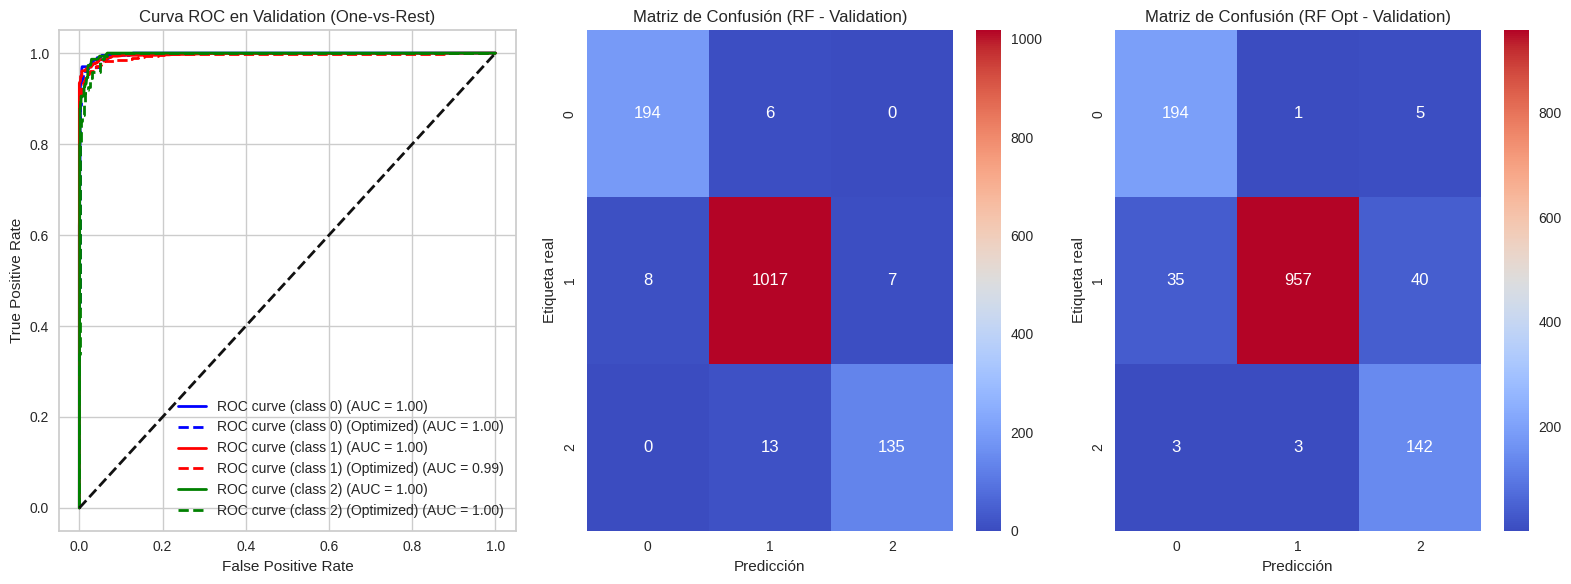

In [20]:
y_eval_bin = label_binarize(y_eval_group, classes=[0, 1, 2])
n_classes = y_eval_bin.shape[1]

plt.figure(figsize=(16, 6))

# Graficamos las Curvas ROC usando validation
plt.subplot(1, 3, 1)
colors = ['blue', 'red', 'green']
for i in range(n_classes):
    fpr_rf, tpr_rf, _ = roc_curve(y_eval_bin[:, i], y_proba[:, i])
    fpr_rf_opt, tpr_rf_opt, _ = roc_curve(y_eval_bin[:, i], y_proba_rf_opt[:, i])
    auc_rf = auc(fpr_rf, tpr_rf)
    auc_rf_opt = auc(fpr_rf_opt, tpr_rf_opt)

    plt.plot(fpr_rf, tpr_rf, color=colors[i], lw=2, label=f'ROC curve (class {i}) (AUC = {auc_rf:.2f})')
    plt.plot(fpr_rf_opt, tpr_rf_opt, color=colors[i], linestyle='--', lw=2, label=f'ROC curve (class {i}) (Optimized) (AUC = {auc_rf_opt:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC en Validation (One-vs-Rest)')
plt.legend(loc="lower right")

# Matrices de Confusión usando validation
cm_rf = confusion_matrix(y_eval_group, y_pred)
plt.subplot(1, 3, 2)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de Confusión (RF - Validation)')

cm_rf_opt = confusion_matrix(y_eval_group, y_pred_rf_opt)
plt.subplot(1, 3, 3)
sns.heatmap(cm_rf_opt, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de Confusión (RF Opt - Validation)')

plt.tight_layout()
plt.show()

En la curva ROC se observa que todas las curvas se aproximan al vértice superior izquierdo, con valores de AUC mayores a 0.99, lo que indica una capacidad de clasificación casi perfecta. En las matrices de confusión, tanto los modelos por defecto como los optimizados muestran desempeños muy similares, clasificando correctamente la gran mayoría de instancias en las tres categorías, con muy pocos errores residuales.

### XGBoost

Ahora vamos a realizar el mismo procedimiento que hicimos en Random Forest, pero con el modelo de XGBoost.
Comenzamos haciendo una validación cruzada con los datos de entrenamiento.

In [21]:
# Instanciamos el modelo
xgb = XGBClassifier(
    random_state=RANDOM_SEED,
    objective='multi:softmax',
    eval_metric='mlogloss'  # Usamos 'mlogloss' para multiclase
)

In [22]:
# Calculamos sample weights para balanceado
classes = np.unique(y_train_group)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_group)
weight_dict = dict(zip(classes, class_weights))
sample_weights = np.array([weight_dict[class_val] for class_val in y_train_group])

print(f"Pesos por clase: {weight_dict}")

Pesos por clase: {0: 2.1904761904761907, 1: 0.46153846153846156, 2: 2.6538461538461537}


In [23]:
# Validación cruzada XGBoost base
def cv_with_sample_weight_xgb(X, y, cv, sample_weights):
    roc_scores = []
    f1_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        sw_train_fold = sample_weights[train_idx]

        model_fold = XGBClassifier(
            random_state=RANDOM_SEED,
            objective='multi:softmax',
            eval_metric='mlogloss'
        )

        model_fold.fit(X_train_fold, y_train_fold, sample_weight=sw_train_fold)
        y_pred_proba = model_fold.predict_proba(X_val_fold)
        y_pred = model_fold.predict(X_val_fold)

        roc_scores.append(roc_auc_score(y_val_fold, y_pred_proba, multi_class='ovr'))
        f1_scores.append(f1_score(y_val_fold, y_pred, average='weighted'))

    return np.array(roc_scores), np.array(f1_scores)

# Evalué con validación cruzada
roc_scores, f1_scores = cv_with_sample_weight_xgb(X_train, y_train_group, cv, sample_weights)

print("Validación Cruzada - XGBoost:")
print(f"ROC-AUC: {roc_scores.mean():.4f} (+/- {roc_scores.std()*2:.4f})")
print(f"F1-Score: {f1_scores.mean():.4f} (+/- {f1_scores.std()*2:.4f})")

Validación Cruzada - XGBoost:
ROC-AUC: 0.9976 (+/- 0.0026)
F1-Score: 0.9765 (+/- 0.0129)


Como el modelo mostró un buen rendimiento en los distintos folds durante la validación cruzada, podemos entrenar un modelo final utilizando todo el conjunto de entrenamiento.

In [24]:
# Entrenamos el modelo completo
xgb.fit(X_train, y_train_group, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Veamos como funciona el modelo entrenado con los datos de validación.

In [25]:
y_pred_xgb = xgb.predict(X_eval)
y_proba_xgb = xgb.predict_proba(X_eval)

print("XGBoost base en Validation:")
print(f"F1 Score: {f1_score(y_eval_group, y_pred_xgb, average='weighted'):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_eval_group, y_proba_xgb, multi_class='ovr'):.4f}")

XGBoost base en Validation:
F1 Score: 0.9741
ROC-AUC: 0.9969


Ahora ajustaremos los hiperparámetros para encontrar los mejores.

In [26]:
param_xgb = {
    'n_estimators': Integer(200, 2000),
    'max_depth': Integer(3, 8),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
    'subsample': Real(0.7, 1.0, prior='uniform'),
    'colsample_bytree': Real(0.7, 1.0, prior='uniform'),
    'min_child_weight': Integer(1, 6),
    'gamma': Real(0, 2, prior='uniform'),
    'reg_lambda': Real(1e-2, 10, prior='log-uniform'),
    'reg_alpha': Real(1e-2, 10, prior='log-uniform')
}

In [27]:
# Para la optimización, usamos XGBoost sin sample_weight en BayesSearchCV
# y luego reentrenamos con sample_weight
xgb_for_opt = XGBClassifier(
    random_state=RANDOM_SEED,
    objective='multi:softmax',
    eval_metric='mlogloss'
)

xgb_opt_search = BayesSearchCV(
    estimator=xgb_for_opt,
    search_spaces=param_xgb,
    n_iter=BAYES_SEARCH_ITER,
    scoring='roc_auc_ovr',
    cv=cv,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

print("Optimizando hiperparámetros XGBoost...")
xgb_opt_search.fit(X_train, y_train_group)

print("Mejores hiperparámetros XGBoost:")
print(xgb_opt_search.best_params_)
print(f"ROC-AUC (sin sample weights): {xgb_opt_search.best_score_:.4f}")

Optimizando hiperparámetros XGBoost...
Fitting 10 folds for each of 1 candidates, totalling 10 fits


/home/jalbiero/bin/anaconda3/envs/mentoria/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/jalbiero/bin/anaconda3/envs/mentoria/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the

Mejores hiperparámetros XGBoost:
OrderedDict({'colsample_bytree': 0.8592892494856442, 'gamma': 1.3521590177538272, 'learning_rate': 0.06458981888721284, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 1965, 'reg_alpha': 0.02422177518749891, 'reg_lambda': 0.010113718979245269, 'subsample': 0.875810527665426})
ROC-AUC (sin sample weights): 0.9970


Creamos el modelo final de XGBoost con mejores hiperparámetros Y sample weights

In [28]:
xgb_opt = XGBClassifier(
    random_state=RANDOM_SEED,
    objective='multi:softmax',
    eval_metric='mlogloss',
    **xgb_opt_search.best_params_
)

# Entrenamos con sample weights
xgb_opt.fit(X_train, y_train_group, sample_weight=sample_weights)

# Evaluamos modelo optimizado en validation
y_pred_xgb_opt = xgb_opt.predict(X_eval)
y_proba_xgb_opt = xgb_opt.predict_proba(X_eval)

print("XGBoost base en Validation:")
print(f"F1 Score: {f1_score(y_eval_group, y_pred_xgb, average='weighted'):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_eval_group, y_proba_xgb, multi_class='ovr'):.4f}")

print("==========")

print("XGBoost optimizado en Validation:")
print(f"F1 Score: {f1_score(y_eval_group, y_pred_xgb_opt, average='weighted'):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_eval_group, y_proba_xgb_opt, multi_class='ovr'):.4f}")

XGBoost base en Validation:
F1 Score: 0.9741
ROC-AUC: 0.9969
XGBoost optimizado en Validation:
F1 Score: 0.9554
ROC-AUC: 0.9960


Veamos las variables más importantes para la clasificación.

In [29]:
feature_importance_xgb = xgb_opt.feature_importances_
feature_df_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance_xgb
}).sort_values('Importance', ascending=False)

print("Top 10 features más importantes - XGBoost:")
print(tabulate(feature_df_xgb.head(10), headers="keys", tablefmt="github", floatfmt=".6f", showindex=False))

Top 10 features más importantes - XGBoost:
| Feature                        |   Importance |
|--------------------------------|--------------|
| RCS_SIZE_ENC                   |     0.243844 |
| LAUNCH_MASS_KG                 |     0.163534 |
| LAUNCH_YEAR                    |     0.111358 |
| PURPOSE_COMMUNICATIONS         |     0.111178 |
| PURPOSE_TECHNOLOGY_DEVELOPMENT |     0.050726 |
| APOGEE                         |     0.046073 |
| PERIOD                         |     0.039799 |
| COUNTRY_GROUPED_UK             |     0.037731 |
| CLASS_OF_ORBIT_ENC             |     0.027961 |
| COUNTRY_GROUPED_PRC            |     0.024640 |


En esta tabla podemos ver nuevamente que tanto el tamaño como el peso de los objetos son importantes para clasificar su expectativa de vida. Sin embargo, también aparece que saber si el propósito del satélite es comunicación, parece facilitar la clasificación.

Creamos la matriz de confusión y graficamos las curvas ROC en el caso OVR (One vs Rest).

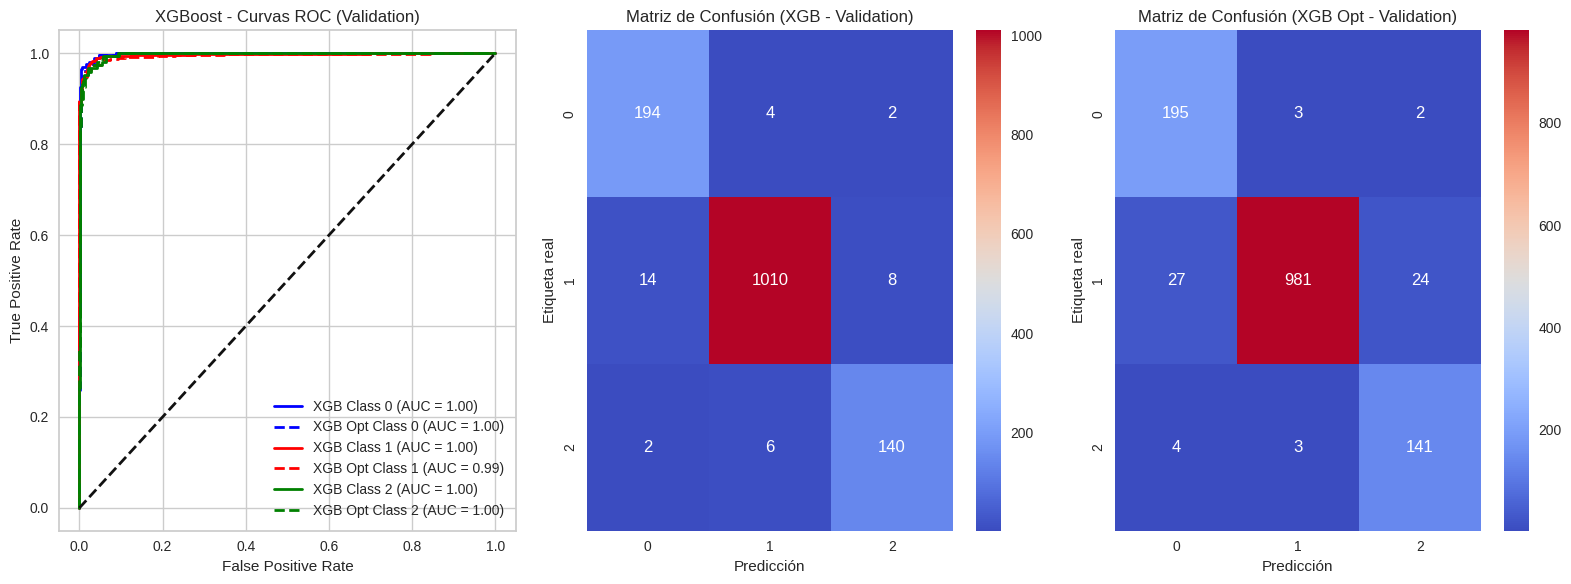

In [30]:
y_eval_bin = label_binarize(y_eval_group, classes=[0, 1, 2])
n_classes = y_eval_bin.shape[1]

plt.figure(figsize=(16, 6))

# Curvas ROC XGBoost
plt.subplot(1, 3, 1)
colors = ['blue', 'red', 'green']
for i in range(n_classes):
    fpr_xgb, tpr_xgb, _ = roc_curve(y_eval_bin[:, i], y_proba_xgb[:, i])
    fpr_xgb_opt, tpr_xgb_opt, _ = roc_curve(y_eval_bin[:, i], y_proba_xgb_opt[:, i])
    auc_xgb = auc(fpr_xgb, tpr_xgb)
    auc_xgb_opt = auc(fpr_xgb_opt, tpr_xgb_opt)

    plt.plot(fpr_xgb, tpr_xgb, color=colors[i], lw=2, label=f'XGB Class {i} (AUC = {auc_xgb:.2f})')
    plt.plot(fpr_xgb_opt, tpr_xgb_opt, color=colors[i], linestyle='--', lw=2, label=f'XGB Opt Class {i} (AUC = {auc_xgb_opt:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost - Curvas ROC (Validation)')
plt.legend(loc="lower right")

# Matrices de Confusión XGBoost
cm_xgb = confusion_matrix(y_eval_group, y_pred_xgb)
plt.subplot(1, 3, 2)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de Confusión (XGB - Validation)')

cm_xgb_opt = confusion_matrix(y_eval_group, y_pred_xgb_opt)
plt.subplot(1, 3, 3)
sns.heatmap(cm_xgb_opt, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de Confusión (XGB Opt - Validation)')

plt.tight_layout()
plt.show()

Nuevamente, ambos modelos muestran un desempeño cercano a la clasificación perfecta. En este caso, algunas métricas del modelo optimizado resultan levemente mejores y otras levemente peores respecto al modelo por defecto. En particular, el optimizado tiende a clasificar un poco peor la clase más abundante, pero mejora ligeramente en las clases menos representadas.

### Support Vector Machine

Por último, veamos Support Vector Machine.

Comenzamos haciendo una validación cruzada con los datos de entrenamiento y el modelo por defecto.

In [31]:
svm = SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED, class_weight='balanced')

scores_smv = cross_validate(
    svm,
    X_train,
    y_train_group,
    cv=cv,
    scoring=['roc_auc_ovr', 'f1_weighted'],
    return_train_score=False

)

metrics_table = [
    ["ROC-AUC", [f"{v:.4f}" for v in scores_smv['test_roc_auc_ovr']], f"{scores_smv['test_roc_auc_ovr'].mean():.4f}"],
    ["F1 Score", [f"{v:.4f}" for v in scores_smv['test_f1_weighted']], f"{scores_smv['test_f1_weighted'].mean():.4f}"]
]

print(tabulate(metrics_table, headers=["Métrica", "Scores por fold", "Media"], tablefmt="github"))

| Métrica   | Scores por fold                                                                                      |   Media |
|-----------|------------------------------------------------------------------------------------------------------|---------|
| ROC-AUC   | ['0.9912', '0.9888', '0.9905', '0.9879', '0.9931', '0.9927', '0.9957', '0.9959', '0.9932', '0.9956'] |  0.9925 |
| F1 Score  | ['0.9378', '0.9622', '0.9368', '0.9364', '0.9555', '0.9460', '0.9605', '0.9577', '0.9395', '0.9553'] |  0.9488 |


Como el modelo mostró un buen rendimiento en los distintos folds durante la validación cruzada, podemos entrenar un modelo base.

In [32]:
# Entrenamos el modelo
svm.fit(X_train, y_train_group)

SVC(class_weight='balanced', probability=True, random_state=0)

Veamos como funciona el modelo entrenado con los datos de validación.

In [33]:
y_pred_svm = svm.predict(X_eval)
y_proba_svm = svm.predict_proba(X_eval)

print("SVM base en Validation:")
print(f"F1 Score: {f1_score(y_eval_group, y_pred_svm, average='weighted'):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_eval_group, y_proba_svm, multi_class='ovr'):.4f}")

SVM base en Validation:
F1 Score: 0.9458
ROC-AUC: 0.9937


Ahora ajustaremos los hiperparámetros.

In [34]:
param_svm = {
    'C': Real(1e-2, 1e3, prior='log-uniform'),
    'gamma': Real(1e-6, 1e1, prior='log-uniform')
}

In [35]:
svm_opt = BayesSearchCV(
    estimator=svm,
    search_spaces=param_svm,
    n_iter=BAYES_SEARCH_ITER,
    scoring='roc_auc_ovr',
    cv=cv,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

print("Optimizando hiperparámetros SVM...")
svm_opt.fit(X_train, y_train_group)

print("Mejores hiperparámetros SVM:")
print(svm_opt.best_params_)
print(f"ROC-AUC: {svm_opt.best_score_:.4f}")

Optimizando hiperparámetros SVM...
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Mejores hiperparámetros SVM:
OrderedDict({'C': 4.516695623193222, 'gamma': 0.054020246568608606})
ROC-AUC: 0.9892


In [36]:
svm_opt

BayesSearchCV(cv=StratifiedKFold(n_splits=10, random_state=0, shuffle=True),
              estimator=SVC(class_weight='balanced', probability=True,
                            random_state=0),
              n_iter=1, n_jobs=-1, random_state=0, scoring='roc_auc_ovr',
              search_spaces={'C': Real(low=0.01, high=1000.0, prior='log-uniform', transform='normalize'),
                             'gamma': Real(low=1e-06, high=10.0, prior='log-uniform', transform='normalize')},
              verbose=1)

Veamos las métricas del modelo óptimo con los datos de validación:

In [37]:
y_pred_svm_opt = svm_opt.predict(X_eval)
y_proba_svm_opt = svm_opt.predict_proba(X_eval)

print("SVM base en Validation:")
print(f"F1 Score: {f1_score(y_eval_group, y_pred_svm, average='weighted'):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_eval_group, y_proba_svm, multi_class='ovr'):.4f}")

print("======")

print("SVM optimizado en Validation:")
print(f"F1 Score: {f1_score(y_eval_group, y_pred_svm_opt, average='weighted'):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_eval_group, y_proba_svm_opt, multi_class='ovr'):.4f}")

SVM base en Validation:
F1 Score: 0.9458
ROC-AUC: 0.9937
SVM optimizado en Validation:
F1 Score: 0.9299
ROC-AUC: 0.9909


Creamos la matriz de confusión y graficamos las curvas ROC en el caso OVR (One vs Rest).

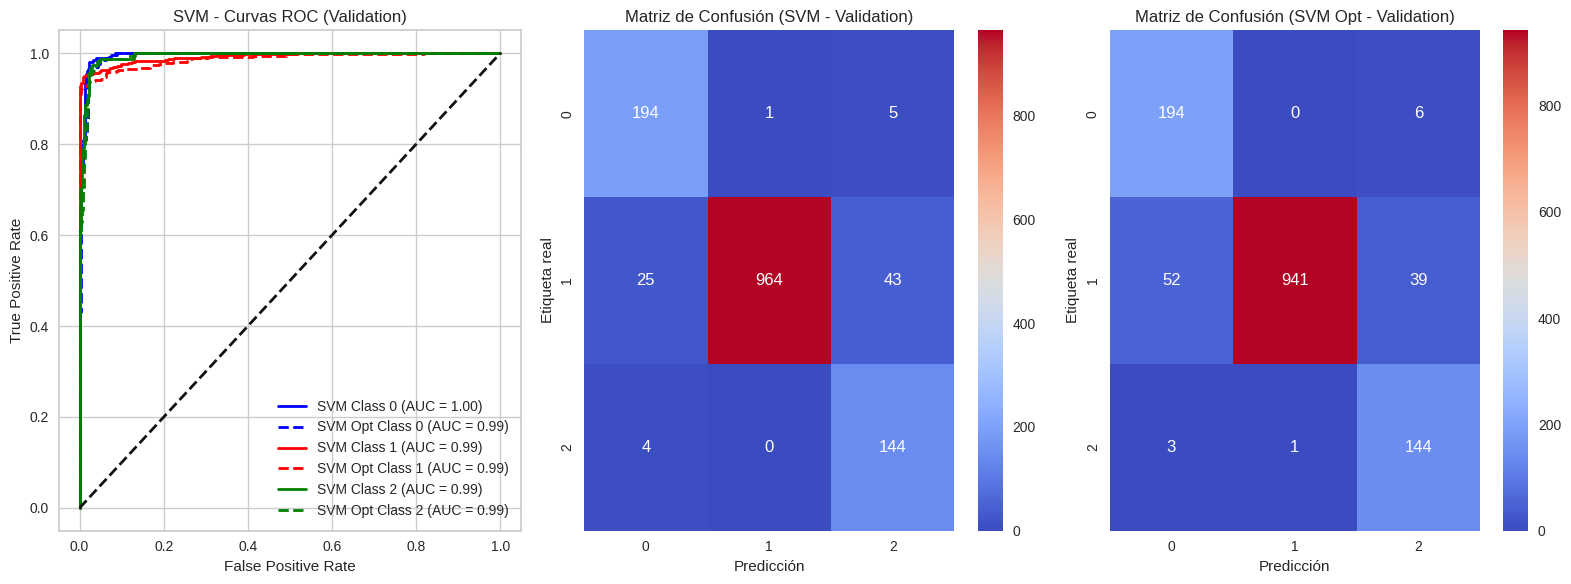

In [38]:
plt.figure(figsize=(16, 6))

# Curvas ROC SVM
plt.subplot(1, 3, 1)
colors = ['blue', 'red', 'green']
for i in range(n_classes):
    fpr_svm, tpr_svm, _ = roc_curve(y_eval_bin[:, i], y_proba_svm[:, i])
    fpr_svm_opt, tpr_svm_opt, _ = roc_curve(y_eval_bin[:, i], y_proba_svm_opt[:, i])
    auc_svm = auc(fpr_svm, tpr_svm)
    auc_svm_opt = auc(fpr_svm_opt, tpr_svm_opt)

    plt.plot(fpr_svm, tpr_svm, color=colors[i], lw=2, label=f'SVM Class {i} (AUC = {auc_svm:.2f})')
    plt.plot(fpr_svm_opt, tpr_svm_opt, color=colors[i], linestyle='--', lw=2, label=f'SVM Opt Class {i} (AUC = {auc_svm_opt:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM - Curvas ROC (Validation)')
plt.legend(loc="lower right")

# Matrices de Confusión SVM
cm_svm = confusion_matrix(y_eval_group, y_pred_svm)
plt.subplot(1, 3, 2)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de Confusión (SVM - Validation)')

cm_svm_opt = confusion_matrix(y_eval_group, y_pred_svm_opt)
plt.subplot(1, 3, 3)
sns.heatmap(cm_svm_opt, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de Confusión (SVM Opt - Validation)')

plt.tight_layout()
plt.show()

Por último, en el caso de SVM ambos modelos (por defecto y optimizado) logran una clasificación muy buena. Algunas métricas favorecen al optimizado y otras al modelo por defecto, aunque al observar la matriz de confusión se aprecia un ligero mejor desempeño del modelo por defecto.

### 4. Comparación de Modelos y Selección del Mejor Modelo

Ahora que ya entrenamos todos los modelos y evaluamos su desempeño en el conjunto de validación, vamos a seleccionar el mejor de ellos utilizando este mismo conjunto. El criterio de selección será el puntaje de ROC-AUC, eligiendo como mejor modelo aquel que obtenga el valor más alto en esta métrica.

In [39]:
models = {
    'RF': rf,
    'RF_Opt': rf_opt.best_estimator_,
    'XGB': xgb,
    'XGB_Opt': xgb_opt,
    'SVM': svm,
    'SVM_Opt': svm_opt.best_estimator_
}

In [40]:
validation_results = []

for name, model in models.items():
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)

    # Métricas completas
    accuracy = accuracy_score(y_eval_group, y_pred)
    roc_auc = roc_auc_score(y_eval_group, y_proba, multi_class='ovr')
    f1_macro = f1_score(y_eval_group, y_pred, average='macro')
    f1_weighted = f1_score(y_eval_group, y_pred, average='weighted')
    balanced_acc = balanced_accuracy_score(y_eval_group, y_pred)
    precision = precision_score(y_eval_group, y_pred, average='weighted')
    recall = recall_score(y_eval_group, y_pred, average='weighted')

    validation_results.append({
        'Modelo': name,
        'Accuracy': accuracy,
        'Balanced_Acc': balanced_acc,
        'ROC_AUC': roc_auc,
        'F1_Macro': f1_macro,
        'F1_Weighted': f1_weighted,
        'Precision': precision,
        'Recall': recall
    })

validation_df = pd.DataFrame(validation_results).sort_values('ROC_AUC', ascending=False)

print("RESULTADOS EN VALIDATION DATA:")
print(tabulate(validation_df, headers="keys", tablefmt="github", floatfmt=".4f", showindex=False))

best_model_name = validation_df.iloc[0]['Modelo']
best_model = models[best_model_name]
best_score = validation_df.iloc[0]['ROC_AUC']

print(f"\n🏆 MEJOR MODELO: {best_model_name}")
print(f"   ROC-AUC en Validation: {best_score:.4f}")

RESULTADOS EN VALIDATION DATA:
| Modelo   |   Accuracy |   Balanced_Acc |   ROC_AUC |   F1_Macro |   F1_Weighted |   Precision |   Recall |
|----------|------------|----------------|-----------|------------|---------------|-------------|----------|
| RF       |     0.9754 |         0.9559 |    0.9972 |     0.9599 |        0.9753 |      0.9753 |   0.9754 |
| XGB      |     0.9739 |         0.9649 |    0.9969 |     0.9568 |        0.9741 |      0.9745 |   0.9739 |
| XGB_Opt  |     0.9543 |         0.9594 |    0.9960 |     0.9275 |        0.9554 |      0.9589 |   0.9543 |
| RF_Opt   |     0.9370 |         0.9523 |    0.9957 |     0.9021 |        0.9393 |      0.9473 |   0.9370 |
| SVM      |     0.9435 |         0.9590 |    0.9937 |     0.9099 |        0.9458 |      0.9536 |   0.9435 |
| SVM_Opt  |     0.9268 |         0.9516 |    0.9909 |     0.8907 |        0.9299 |      0.9417 |   0.9268 |

🏆 MEJOR MODELO: RF
   ROC-AUC en Validation: 0.9972


A pesar de que todos los modelos clasifican con métricas muy altas, el mejor modelo, teniendo en cuenta la métrica elegida, es el Random Forest optimizado. Ahora hagamos un análisis detallado de este mejor modelo.

===ANÁLISIS DETALLADO - RF (VALIDATION) ===
              precision    recall  f1-score   support

  Vida Corta       0.96      0.97      0.97       200
  Vida Media       0.98      0.99      0.98      1032
  Vida Larga       0.95      0.91      0.93       148

    accuracy                           0.98      1380
   macro avg       0.96      0.96      0.96      1380
weighted avg       0.98      0.98      0.98      1380



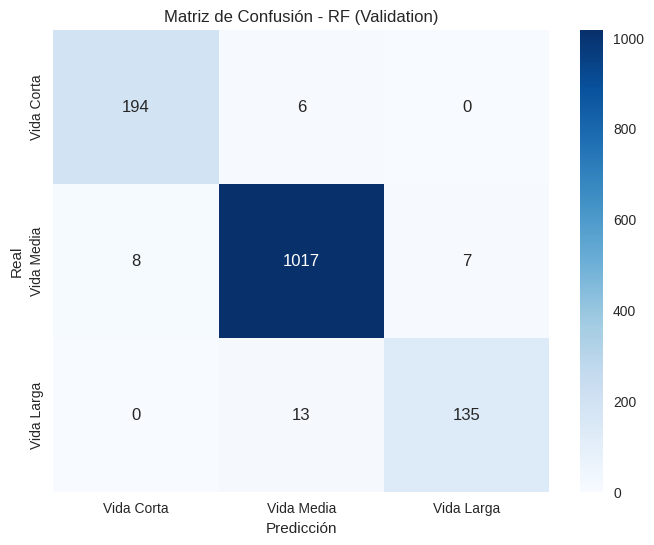

In [41]:
y_pred_best = best_model.predict(X_eval)
y_proba_best = best_model.predict_proba(X_eval)

print(f"===ANÁLISIS DETALLADO - {best_model_name} (VALIDATION) ===")
print(classification_report(y_eval_group, y_pred_best,
                          target_names=['Vida Corta', 'Vida Media', 'Vida Larga']))

# Matriz de confusión del mejor modelo
cm_best = confusion_matrix(y_eval_group, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Vida Corta', 'Vida Media', 'Vida Larga'],
           yticklabels=['Vida Corta', 'Vida Media', 'Vida Larga'])
plt.title(f'Matriz de Confusión - {best_model_name} (Validation)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

El modelo seleccionado (RF_Opt) logra un 98% de accuracy en validación, con un desempeño muy alto en todas las clases. La clase mayoritaria (“Vida Media”) se clasifica casi a la perfección, mientras que las minoritarias (“Vida Corta” y “Vida Larga”) también presentan métricas muy buenas, aunque algo menores.

Comparemos las métricas de los modelos y un gráfico con todas las métricas del modelo seleccionado:

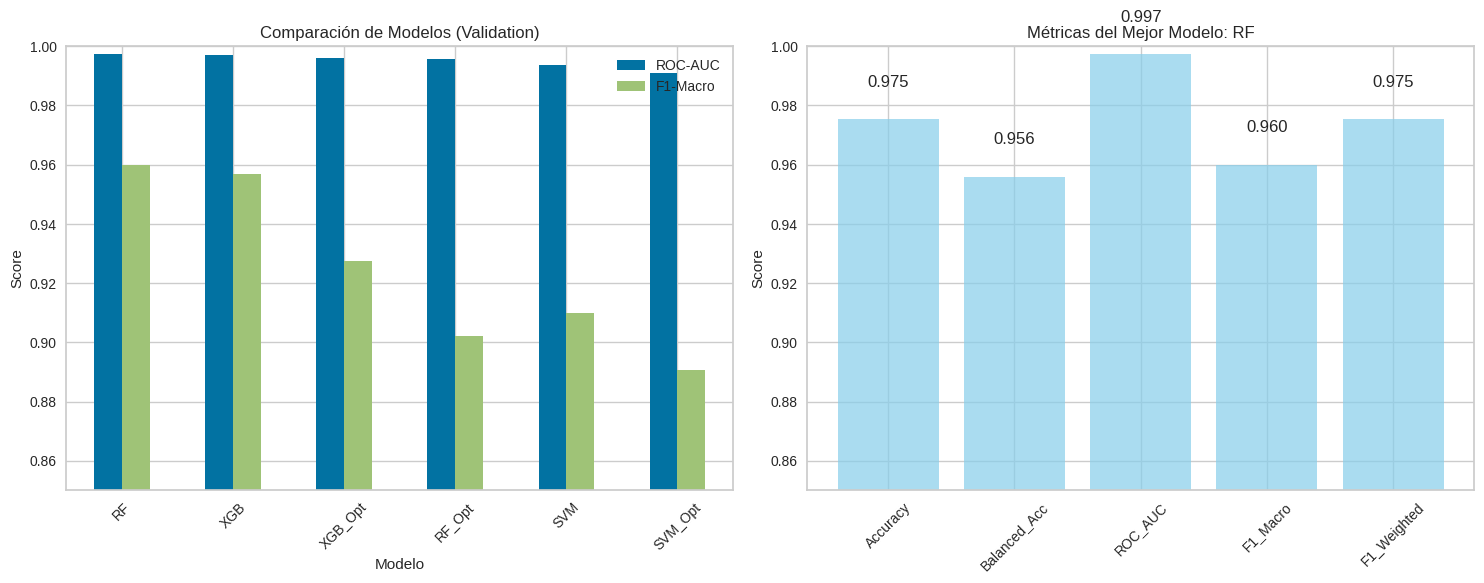

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras - ROC-AUC
validation_df_plot = validation_df.set_index('Modelo')
validation_df_plot[['ROC_AUC', 'F1_Macro']].plot(kind='bar', ax=ax1)
ax1.set_title('Comparación de Modelos (Validation)')
ax1.set_ylabel('Score')
ax1.legend(['ROC-AUC', 'F1-Macro'])
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylim(0.85, 1.0)

# Gráfico de barras - Todas las métricas del mejor modelo
best_row = validation_df[validation_df['Modelo'] == best_model_name].iloc[0]
metrics_best = ['Accuracy', 'Balanced_Acc', 'ROC_AUC', 'F1_Macro', 'F1_Weighted']
values_best = [best_row[metric] for metric in metrics_best]

ax2.bar(metrics_best, values_best, color='skyblue', alpha=0.7)
ax2.set_title(f'Métricas del Mejor Modelo: {best_model_name}')
ax2.set_ylabel('Score')
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylim(0.85, 1.0)

# Agregamos valores en las barras
for i, v in enumerate(values_best):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


Podemos ver que la ROC-AUC muestra valores muy altos y consistentes en todos los modelos, mientras que la F1-Macro varía un poco más entre ellos. En el caso del modelo elegido, todas las métricas se ubican por encima de 0.95, con algunas más destacadas que otras, lo que confirma su solidez y buen desempeño general.

### 5. Evaluación final con los datos de testeo

Con el modelo final ya seleccionado, evaluaremos ahora su desempeño en el conjunto de testeo, un conjunto de datos completamente nuevo que el modelo no vio durante el entrenamiento ni la validación.

In [43]:
y_pred_final = best_model.predict(X_test)
y_proba_final = best_model.predict_proba(X_test)

final_accuracy = accuracy_score(y_test_group, y_pred_final)
final_balanced_acc = balanced_accuracy_score(y_test_group, y_pred_final)
final_roc_auc = roc_auc_score(y_test_group, y_proba_final, multi_class='ovr')
final_f1_macro = f1_score(y_test_group, y_pred_final, average='macro')
final_f1_weighted = f1_score(y_test_group, y_pred_final, average='weighted')
final_precision = precision_score(y_test_group, y_pred_final, average='weighted')
final_recall = recall_score(y_test_group, y_pred_final, average='weighted')

print(f" === RESULTADOS FINALES - {best_model_name} (TEST): ===")
print(f"   Accuracy:          {final_accuracy:.4f}")
print(f"   Balanced Accuracy: {final_balanced_acc:.4f}")
print(f"   ROC-AUC:          {final_roc_auc:.4f}")
print(f"   F1-Macro:         {final_f1_macro:.4f}")
print(f"   F1-Weighted:      {final_f1_weighted:.4f}")
print(f"   Precision:        {final_precision:.4f}")
print(f"   Recall:           {final_recall:.4f}")

 === RESULTADOS FINALES - RF (TEST): ===
   Accuracy:          0.9739
   Balanced Accuracy: 0.9552
   ROC-AUC:          0.9978
   F1-Macro:         0.9567
   F1-Weighted:      0.9739
   Precision:        0.9739
   Recall:           0.9739


In [44]:
print(f"=== REPORTE DETALLADO - {best_model_name} (TEST) ===")
print(classification_report(y_test_group, y_pred_final,
                          target_names=['Vida Corta', 'Vida Media', 'Vida Larga']))

=== REPORTE DETALLADO - RF (TEST) ===
              precision    recall  f1-score   support

  Vida Corta       0.95      0.98      0.96       205
  Vida Media       0.98      0.98      0.98      1026
  Vida Larga       0.94      0.91      0.93       150

    accuracy                           0.97      1381
   macro avg       0.96      0.96      0.96      1381
weighted avg       0.97      0.97      0.97      1381



En el conjunto de testeo, el modelo seleccionado (RF_Opt) alcanza un 97% de accuracy y un macro F1 de 0.95, mostrando un excelente desempeño general y buena capacidad de generalización. La clase mayoritaria ("Vida Media") se clasifica casi a la perfección, mientras que las clases minoritarias ("Vida Corta" y "Vida Larga") mantienen métricas muy altas, consistentes con los resultados obtenidos en validación.

También podemos comparar los resultados en el conjunto de validación con el conjunto de testeo:

In [45]:
comparison_final = pd.DataFrame({
    'Dataset': ['Validation', 'Test'],
    'Accuracy': [best_row['Accuracy'], final_accuracy],
    'ROC_AUC': [best_row['ROC_AUC'], final_roc_auc],
    'F1_Macro': [best_row['F1_Macro'], final_f1_macro],
    'F1_Weighted': [best_row['F1_Weighted'], final_f1_weighted]
})

print("=== COMPARACIÓN VALIDATION vs TEST ===")
print(tabulate(comparison_final, headers="keys", tablefmt="github", floatfmt=".4f", showindex=False))

=== COMPARACIÓN VALIDATION vs TEST ===
| Dataset    |   Accuracy |   ROC_AUC |   F1_Macro |   F1_Weighted |
|------------|------------|-----------|------------|---------------|
| Validation |     0.9754 |    0.9972 |     0.9599 |        0.9753 |
| Test       |     0.9739 |    0.9978 |     0.9567 |        0.9739 |


Observamos que el modelo se comporta de muy buena forma en ambos, obteniendo métricas altas. Esto nos muestra la robustez del modelo frente a nuevos datos.

Como las métricas son muy altas en todos los casos, puede llegar a pensarse en la existencia de un overfitting. Sin embargo, notemos que casi no existe diferencia entre los datos de validación y testeo:

In [46]:
roc_diff = abs(best_row['ROC_AUC'] - final_roc_auc)
f1_diff = abs(best_row['F1_Macro'] - final_f1_macro)

print(f"== ANÁLISIS DE GENERALIZACIÓN: ==")
print(f"   Diferencia ROC-AUC (Val vs Test): {roc_diff:.4f}")
print(f"   Diferencia F1-Macro (Val vs Test): {f1_diff:.4f}")

if roc_diff < 0.02 and f1_diff < 0.02:
    print("Modelo generaliza bien (diferencias < 0.02)")
elif roc_diff < 0.05 and f1_diff < 0.05:
    print("Modelo generaliza aceptablemente (diferencias < 0.05)")
else:
    print("Posible overfitting (diferencias > 0.05)")


== ANÁLISIS DE GENERALIZACIÓN: ==
   Diferencia ROC-AUC (Val vs Test): 0.0006
   Diferencia F1-Macro (Val vs Test): 0.0032
Modelo generaliza bien (diferencias < 0.02)


A continuación, visualizamos el desempeño del modelo final en el conjunto de testeo:

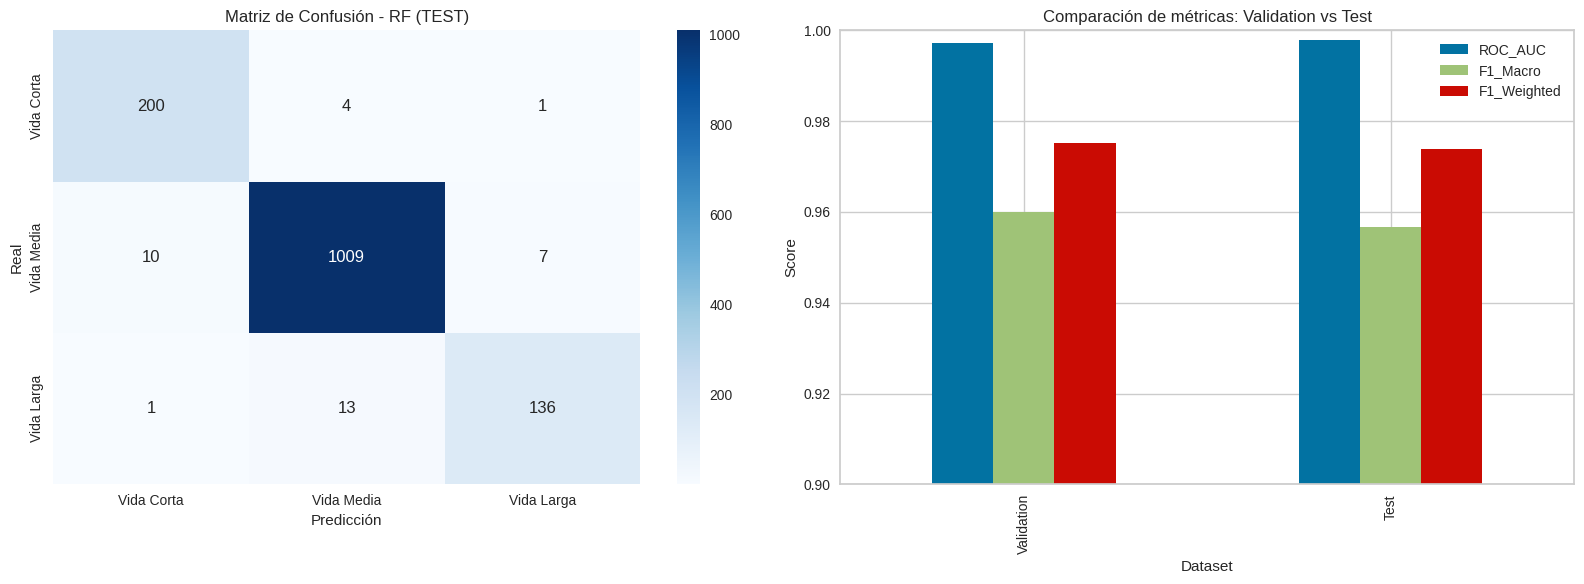

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de confusión
cm_final = confusion_matrix(y_test_group, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Vida Corta', 'Vida Media', 'Vida Larga'],
            yticklabels=['Vida Corta', 'Vida Media', 'Vida Larga'])
axes[0].set_title(f'Matriz de Confusión - {best_model_name} (TEST)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Comparación de métricas
comparison_final.set_index('Dataset')[['ROC_AUC', 'F1_Macro', 'F1_Weighted']].plot(kind='bar',
                                                                                  ax=axes[1])
axes[1].set_title('Comparación de métricas: Validation vs Test')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x')
axes[1].set_ylim(0.9, 1.0)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

El gráfico muestra, a la izquierda, la matriz de confusión del modelo final en testeo, indicando que la mayoría de las predicciones son correctas en las tres clases. A la derecha, se comparan las métricas principales entre validation y test, evidenciando que el modelo mantiene un desempeño alto y consistente, sin signos de sobreajuste.

Visualicemos las curvas ROC por clase y la distribución de predicciones frente a los valores reales:

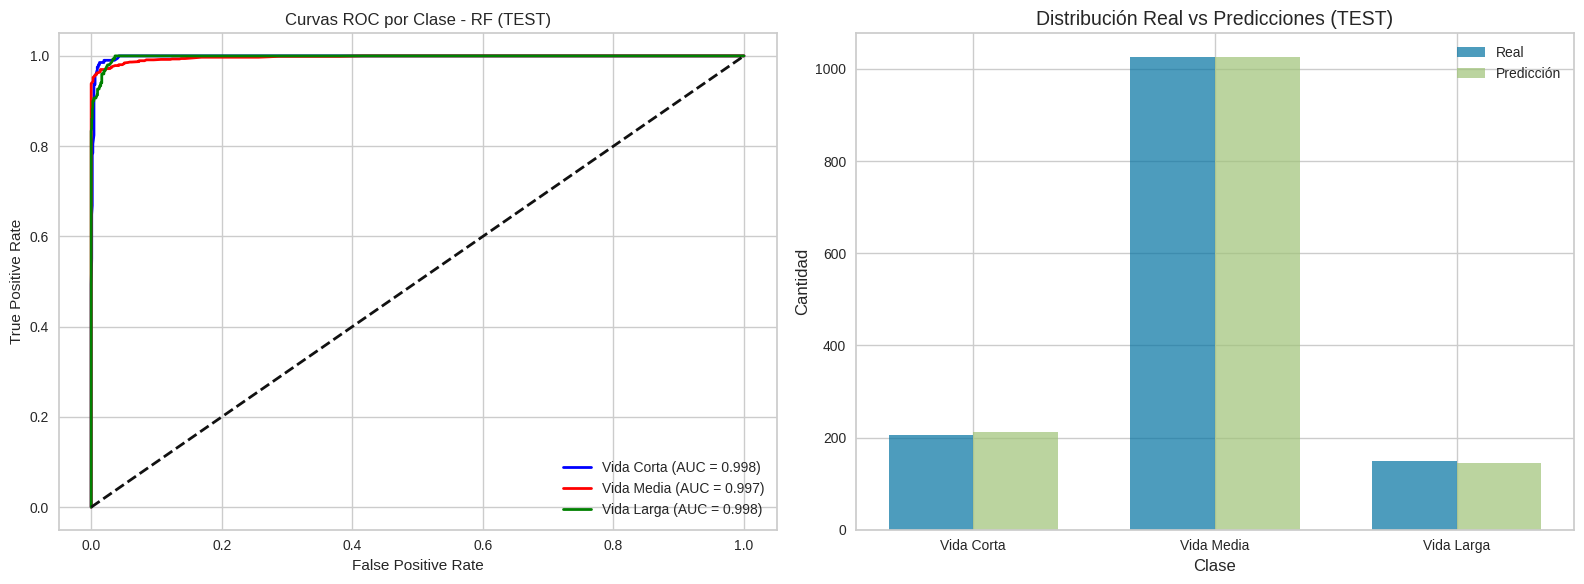

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios':[1,1]})

# Curvas ROC
y_test_bin = label_binarize(y_test_group, classes=[0, 1, 2])
class_names = ['Vida Corta', 'Vida Media', 'Vida Larga']

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_final[:, i])
    roc_auc_class = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=colors[i], lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc_class:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'Curvas ROC por Clase - {best_model_name} (TEST)')
axes[0].legend(loc="lower right")

# Distribución de predicciones vs reales
pred_dist = pd.Series(y_pred_final).value_counts().sort_index()
real_dist = pd.Series(y_test_group).value_counts().sort_index()

x = np.arange(3)
width = 0.35

axes[1].bar(x - width/2, real_dist.values, width, label='Real', alpha=0.7)
axes[1].bar(x + width/2, pred_dist.values, width, label='Predicción', alpha=0.7)
axes[1].set_xlabel('Clase', fontsize=12)
axes[1].set_ylabel('Cantidad', fontsize=12)
axes[1].set_title('Distribución Real vs Predicciones (TEST)', fontsize=14)
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names)
axes[1].legend()

plt.tight_layout()
plt.show()

Las curvas ROC muestran una excelente discriminación para las tres clases, con valores de AUC cercanos a 1. La gráfica de distribución evidencia que las predicciones del modelo siguen muy de cerca la distribución real de las clases, confirmando un desempeño balanceado.

### Conclusiones

En esta primera parte del trabajo se logró clasificar la expectativa de vida de los objetos espaciales en tres categorías: Vida Corta, Vida Media y Vida Larga, utilizando la media y la varianza de la variable como base para la separación.

Se evaluaron tres clasificadores: Random Forest, XGBoost y Support Vector Machine, tanto con sus configuraciones por defecto como optimizados mediante BayesSearch. Todos los modelos mostraron métricas muy altas, lo que indica que los datos presentan una separación notable entre las clases. Las variables con mayor importancia para la clasificación fueron el peso y el tamaño del objeto, seguidas por si el propósito era comunicación o no.

Como mejor modelo se seleccionó el Random Forest optimizado, ya que presentó el mayor ROC-AUC en el conjunto de validación. Al evaluarlo con los datos de testeo, el modelo mantuvo un desempeño excelente en todas las clases, confirmando su robustez y capacidad de generalización.

## Aprendizaje no supervisado

Vamos a tratar de encontrar agrupaciones en los datos mediante los métodos **K-Means** y **DBSCAN** ya que intentaremos agrupar los satélites en base a variables físicas (PERIOD, APOGEE, PERIGEE, etc; ver sección `Estandarización` a continuación para más detalles).

En esta sección de _Aprendizaje no supervisado_ no vamos a necesitar el _dataset_ particionado por lo tanto vamos a reunificarlo.

In [49]:
all_df = pd.concat([train_df, eval_df, test_df], ignore_index=True)
all_df.sample(5)

,INFO_SATNAME,INFO_NORAD_NUMBER,INFO_OBJECT_TYPE,INFO_TYPE_OF_ORBIT,INFO_COUNTRY,INFO_CLASS_OF_ORBIT,PERIOD,INCLINATION,APOGEE,PERIGEE,...,COUNTRY_GROUPED_PRC,COUNTRY_GROUPED_REST,COUNTRY_GROUPED_UK,COUNTRY_GROUPED_US,PURPOSE_COMMUNICATIONS,PURPOSE_EARTH_OBSERVATION,PURPOSE_OTHER,PURPOSE_TECHNOLOGY_DEVELOPMENT,RCS_SIZE_ENC,CLASS_OF_ORBIT_ENC
1743,ONEWEB-0067,45425,PAYLOAD,Polar,UK,LEO,0.016675,0.891527,0.029796,0.030375,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
386,STARLINK-4215,53007,PAYLOAD,Non-Polar Inclined,US,LEO,0.006032,0.539827,0.010969,0.011387,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
6769,STARLINK-1871,47157,PAYLOAD,Non-Polar Inclined,US,LEO,0.006144,0.538102,0.011191,0.011584,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2179,STARLINK-5611,55761,PAYLOAD,Polar,US,LEO,0.006529,0.710096,0.011913,0.012229,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
6189,STARLINK-4089,52831,PAYLOAD,Non-Polar Inclined,US,LEO,0.006032,0.539827,0.010969,0.011387,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0


### Estandarización

Los métodos de _clusterización_ trabajan con distancias, por lo cual es necesitario tener el _dataset_ estandarizado/escalado. Esto ya hizo en el TP2.

Con respecto a las variables categóricas (generadas mediante one hot encoding en el TP2), las mismas no serán tenidas en cuenta, ya que la _clusterización_ trabaja en base a medias y distancias euclídeas, las cuales no están bien definidas para las mismas.


In [50]:
numeric_cols = [
    'PERIOD',
    'INCLINATION',
    'APOGEE',
    'PERIGEE',
    'LAUNCH_MASS_KG',
    'EXPECTED_LIFETIME_YRS',
    'TIME_IN_ORBIT'
]

X = all_df[numeric_cols]

### K-Means

Este método requiere un análisis previo para determinar la cantidad óptima de clústeres (**k**).

#### Elegir la cantidad de clústeres

Obtengamos primero la inercia y el coeficiente de silueta para los posibles valores de **k**.

In [51]:
inertia = []
silhouette = []
possible_ks = range(2, 13)

for k in possible_ks:
    km_model = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init='auto')
    labels = km_model.fit_predict(X)
    inertia.append(km_model.inertia_)
    silhouette.append(silhouette_score(X, labels))

##### Método del codo

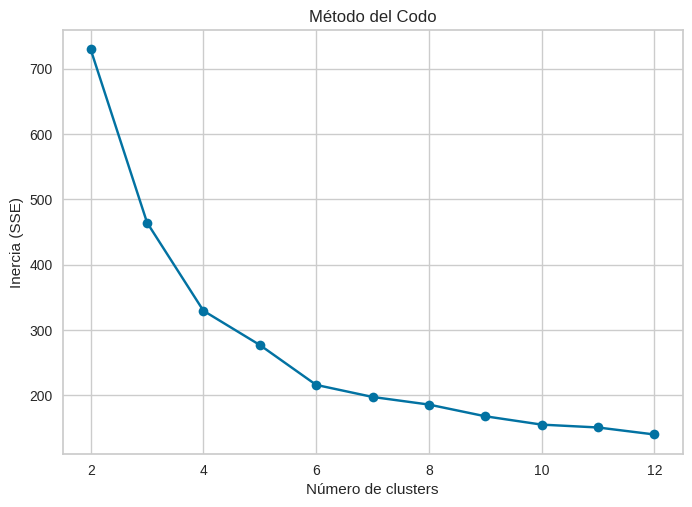

In [52]:
plt.plot(possible_ks, inertia, 'o-')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia (SSE)")
plt.title("Método del Codo")
plt.show()

Si bien 4 podría ser el número de clústeres, no es totalmente claro ya que 6 también podrían serlo.

Veamos que nos dice el **Coeficiente de Silueta** en la sección siguiente.

##### Coeficiente de Silueta

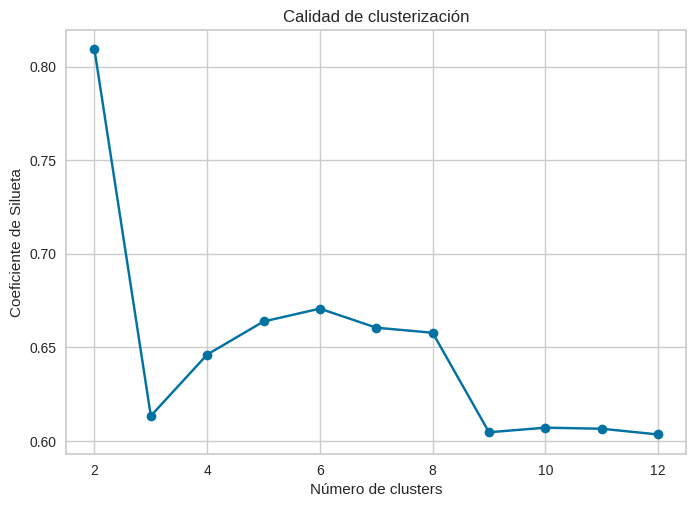

In [53]:
plt.plot(possible_ks, silhouette, 'o-')
plt.xlabel("Número de clusters")
plt.ylabel("Coeficiente de Silueta")
plt.title("Calidad de clusterización")
plt.show()

Según la calidad de la clusterización, valores de **k = 2**, o incluso **6** podrían ser posibles. Veamos en la siguiente sección otro punto de vista.

##### Gráfico de Silueta

Hagmos el gráfico de silueta para los posibles valores de **k**:


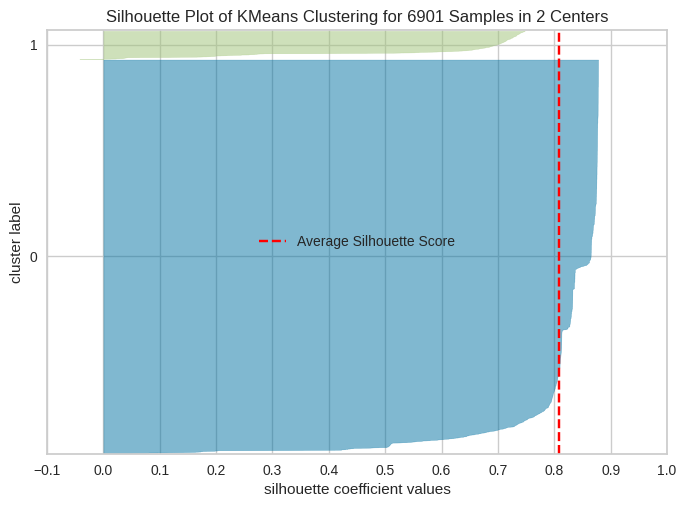

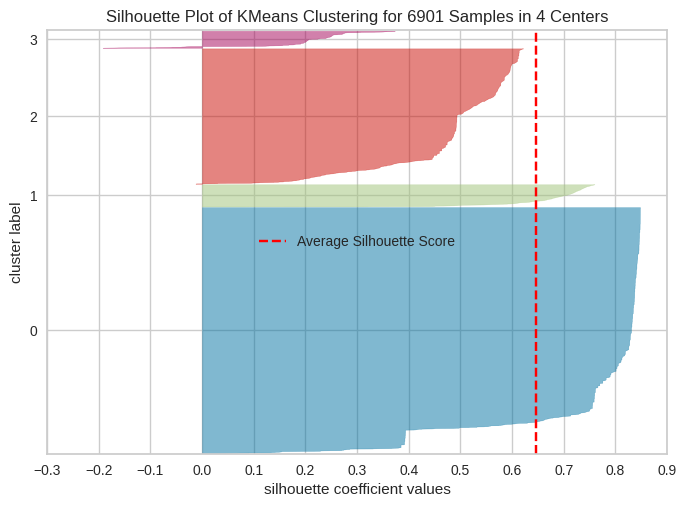

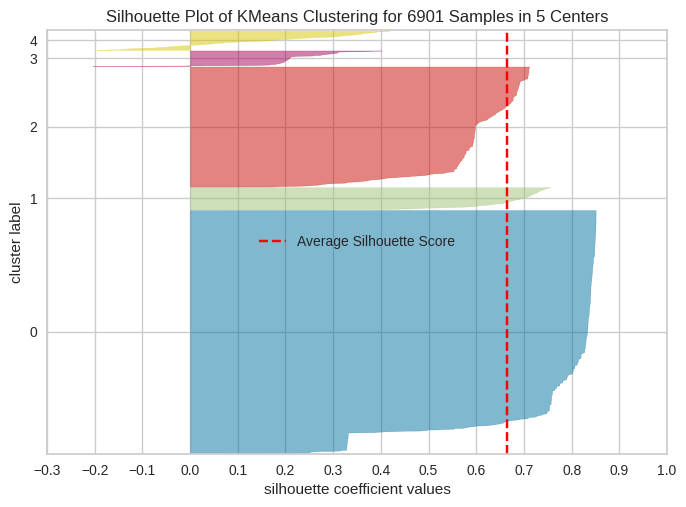

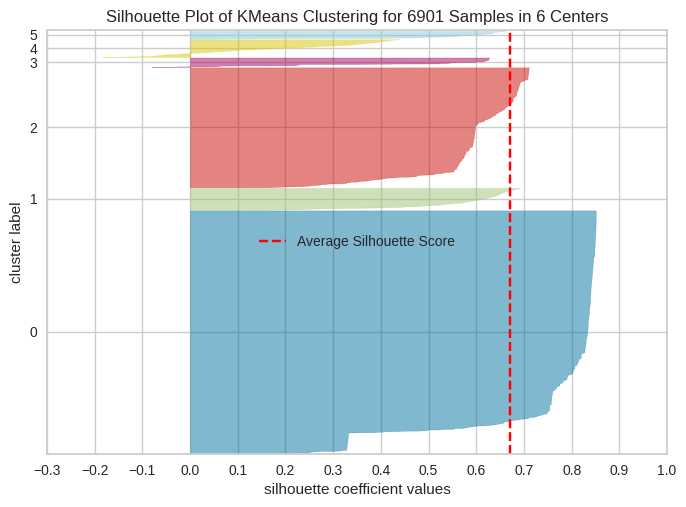

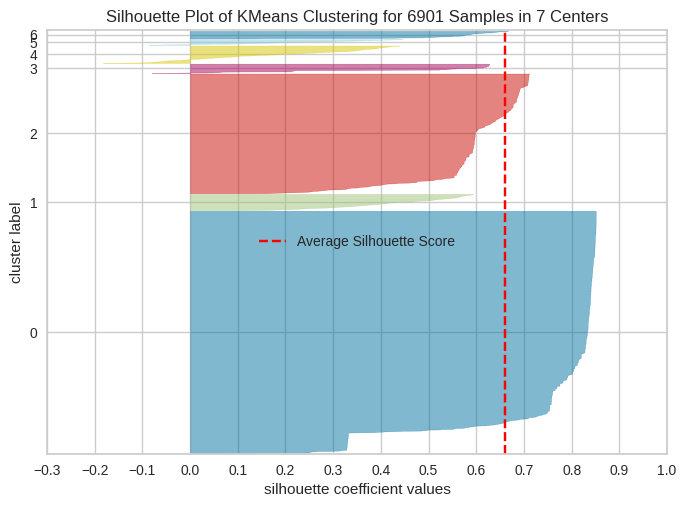

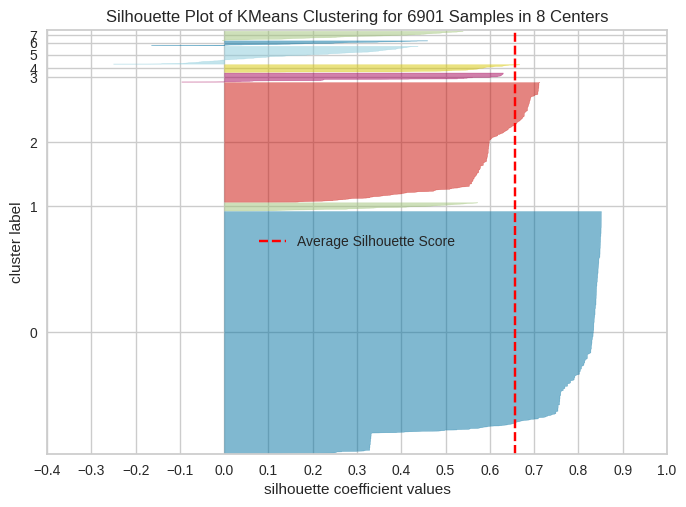

In [54]:
possible_clusters = [2, 4, 5, 6, 7, 8]

for n_clusters in possible_clusters:
  possible_km_model = KMeans(n_clusters=n_clusters, random_state=RANDOM_SEED, n_init='auto')

  visualizer = SilhouetteVisualizer(possible_km_model, colors='yellowbrick')
  visualizer.fit(X)
  visualizer.show()

Los mejores valores parecen ser para **k=2** y para **k=4**, en ambos casos los valores negativos (mal clasificados) son muy pocos. **k=2** aporta poca diversidad a la clasificación, así que nos quedamos con **k=4** (habida cuenta además de que el valor era uno de los posibles en el método del codo).

In [55]:
K_NUM = 4

Costó un poco seleccionar el número correcto de clústeres, ya que los 3 métodos utilizados presentaron información con un dejo de duda, esto si se los tomaba individualmente, pero cuando se los consideró en su conjunto, quedó en claro que 4 clústers es un valor aceptable para la clasificación.

#### Visualización de los clusters

In [56]:
# Algunas funciones de ayuda

from matplotlib.figure import Figure


def plot_3d_via_pca(x_df: DataFrame, all_data_df: DataFrame, clusters: ndarray, title: str | None = None) -> Figure:
    """
    Se usa PCA para reducir la dimensionalidad a 3 para poder graficar:
    """

    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(x_df)

    pca_df = pd.DataFrame()
    pca_df["Pca1"] = X_pca[:, 0]
    pca_df["Pca2"] = X_pca[:, 1]
    pca_df["Pca3"] = X_pca[:, 2]
    pca_df["Cluster"] = clusters
    pca_df["Cluster"] = pca_df["Cluster"].apply(lambda val: "Ruido" if val == -1 else str(val))
    pca_df["Norad"] = all_data_df["INFO_NORAD_NUMBER"]
    pca_df["País"] = all_data_df["INFO_COUNTRY"]
    pca_df["Tipo"] = all_data_df["INFO_OBJECT_TYPE"]
    pca_df["Órbita"] = all_data_df["INFO_CLASS_OF_ORBIT"]

    fig = px.scatter_3d(
        pca_df,
        x="Pca1",
        y="Pca2",
        z="Pca3",
        color="Cluster",
        title="Vista 3D de los clusters" if title is None else title,
        symbol="Cluster",
        hover_data=["Norad", "País", "Tipo", "Órbita"],
        size_max=10,
        color_discrete_sequence=px.colors.qualitative.Set1,
        width=1024,
        height=600
    )

    fig.update_layout(
        legend_title_text="Cluster",
        hovermode="closest",
        scene_camera=dict(eye=dict(x=-1.5, y=1.5, z=1.5)),
    )
    fig.update_traces(
        marker=dict(size=5)
    )

    fig.show()
    return fig


def plot_2d_via_pca(x_df: DataFrame, all_data_df: DataFrame, clusters: ndarray, title: str | None = None) -> None:
    """
    Se usa PCA para reducir la dimensionalidad a 2 para poder graficar:
    """

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(x_df)

    pca_df = pd.DataFrame()
    pca_df["Pca1"] = X_pca[:, 0]
    pca_df["Pca2"] = X_pca[:, 1]
    pca_df["Cluster"] = clusters
    pca_df["Cluster"] = pca_df["Cluster"].apply(lambda val: "Ruido" if val == -1 else str(val))
    pca_df["Norad"] = all_data_df["INFO_NORAD_NUMBER"]
    pca_df["País"] = all_data_df["INFO_COUNTRY"]
    pca_df["Tipo"] = all_data_df["INFO_OBJECT_TYPE"]
    pca_df["Órbita"] = all_data_df["INFO_CLASS_OF_ORBIT"]

    fig = px.scatter(
        pca_df,
        x="Pca1",
        y="Pca2",
        color="Cluster",
        title="Vista 2D de los clusters" if title is None else title,
        symbol="Cluster",
        hover_data=["Norad", "País", "Tipo", "Órbita"],
        size_max=10,
        color_discrete_sequence=px.colors.qualitative.Set1,
        width=1024,
        height=600
    )

    fig.show()

Calculamos los clusters y graficamos, tanto en 2D como en 3D para una mejor inspección:

In [57]:
model = KMeans(n_clusters=K_NUM, random_state=RANDOM_SEED, n_init='auto')
clusters = model.fit_predict(X)

plot_2d_via_pca(X, all_df, clusters, "Clusterización mediante K-Means (vista 2D)")
fig = plot_3d_via_pca(X, all_df, clusters, "Clusterización mediante K-Means (vista 3D)")

Podemos ver que los clústeres determinados están basados básicamente en el tipo de órbita. Para más detalles ver la sección `Conclusiones` al final.

In [58]:
# Para generar video

print("Frames: ", len(fig.frames))

for i, frame in enumerate(fig.frames):
        fig.layout = frame.layout
        fig.data = frame.data
        fig.write_image(f"frame_{i:03d}.png")

Frames:  0


### DBSCAN

Con este método de clusterización no necesitamos especificar el número de clústeres, además, como ventaja, se pueden tener clústeres que no son esféricos o convexos como en el caso de K-Means. Por último, funciona bien con _datasets_ que tienen ruido y _outliers_, al contrario de K-Means donde los ouliers pueden deformar los clústeres de manera poco conveniente.

Calculamos los clústeres (con un valor por defecto de _épsilon_) y graficamos, tanto en 2D como en 3D para una mejor inspección:

In [59]:
model = DBSCAN(eps=0.5, min_samples=5, n_jobs=-1)
clusters = model.fit_predict(X)

plot_2d_via_pca(X, all_df, clusters, "Clusterización mediante DBScan (vista 2D)")
plot_3d_via_pca(X, all_df, clusters, "Clusterización mediante DBScan (vista 3D)")

Con la configuración por defecto del modelo (epsilon = 0.5), DBSCAN agrupa en un mismo clúster (rojo) satélites pertenecientes a las órbitas LEO y MEO. Esto ocurre debido a que las variables físicas consideradas resultan muy sensibles incluso a pequeñas variaciones. Para mejorar la separación entre estas órbitas, procedemos a reducir el valor de epsilon y observar cómo impacta en la conformación de los clústeres.

In [ ]:
model_two = DBSCAN(eps=0.4, min_samples=5, n_jobs=-1)
clusters_two = model_two.fit_predict(X)

plot_2d_via_pca(X, all_df, clusters_two, "Clusterización mediante DBScan (vista 2D)")
plot_3d_via_pca(X, all_df, clusters_two, "Clusterización mediante DBScan (vista 3D)")

Exception ignored in: <function ResourceTracker.__del__ at 0x7f9da2054900>
Traceback (most recent call last):
  File "/home/jalbiero/bin/anaconda3/envs/mentoria/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/jalbiero/bin/anaconda3/envs/mentoria/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/jalbiero/bin/anaconda3/envs/mentoria/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f75dc050900>
Traceback (most recent call last):
  File "/home/jalbiero/bin/anaconda3/envs/mentoria/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/jalbiero/bin/anaconda3/envs/mentoria/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/jalbiero/bin/anaconda3/envs/mentoria/lib/python3.12/multiprocessing/resource_tracker.py", line 

Con un valor de _épsilon_ = 0.4, DBSCAN logra separar de manera adecuada los satélites en órbitas LEO y MEO. Los satélites en GEO, debido a que presentan variables muy distintas respecto de los demás, se agrupan de forma clara en un clúster independiente. El caso más complejo corresponde a los satélites en órbitas elípticas, cuyos valores anómalos en las trayectorias dificultan su clasificación. Si bien el algoritmo identifica un cuarto grupo, una parte considerable de estos mismos es catalogada como ruido, reflejando la naturaleza atípica de este tipo de órbitas.

### Conclusiones

Los métodos de clustering usados arrojaron resultados con similitudes y diferencias:

- K-Means:
  - Basándonos en la información provista por método del codo, coeficiente de silueta, y gráfico de silueta, determinamos que el valor más óptimo para la cantidad de clústeres es **k=4**.
  - Los clústeres determinados están basados básicamente en el tipo de órbita.
  - Los satélites en la órbita LEO fueron divididos en dos grupos (clúster rojo y azul). El método no pudo unificar los clústeres para el mismo tipo de órbita, incluso seleccionando un **k=3**.
  - Los satélites en MEO (clúster violeta) fueron agrupados correctamente, aunque con cierto solapamiento con LEO probablemente debido a la naturaleza intermedia de sus valores orbitales.
  - Satélites en GEO (clúster verde) fueron también correctamente identificados.
  - Órbitas elípticas no fueron detectadas como tal en un clúster propio.

- DBSCAN:
  - Este algoritmo permitió identificar 4 clústeres principales (al igual que K-Means) con valores de _épsilon_ entre 0.4 y 0.5. A diferencia de K-Means, DBSCAN logró separar correctamente los satélites en LEO (en un sólo clúster), MEO (en 2 clústeres), GEO, y un cuarto grupo correspondiente a órbitas elípticas al que el algoritmo no clasifica como clúster en sí, sino como ruido (valor anormal).
  - Este último resultado es particularmente valioso, ya que los satélites en órbitas elípticas son más complejos de clasificar debido a la gran variabilidad de sus parámetros orbitales, lo que coincide con su naturaleza atípica respecto a los clústeres principales. En definitiva, el ruido para el algoritmo puede ser visto como un clúster en sí mismo para nosotros.
  - A diferencia de K-Means, DBSCAN subdividió los satélites en MEO en dos grupos.
  - Una conclusión adicional es que el parámetro _épsilon_ mostró ser altamente sensible, lo que se explica por la cantidad y diversidad de variables físicas incluidas en el análisis.